In [2]:
import numpy as np
from utils.potential import Gravitational_potential_cuboid
from utils.acceleration import gravitational_gx_cuboid, gravitational_gy_cuboid, gravitational_gz_cuboid

In [3]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

##### Potential Evaluation

In [11]:
# Constants and point of evaluation
G = 1  # Gravitational constant
roh = 1  # Density
X_0, Y_0, Z_0 = 0, 0, 0
L, B, D = 1.0, 1.0, 1.0
x, y, z = 0, 0, 0

# Evaluate potential
V = Gravitational_potential_cuboid((x - X_0), (y - Y_0), (z - Z_0), L/2, B/2, D/2, roh, G)
print(f"The gravitational potential at point ({x}, {y}, {z}) is {V:.10e} m^2/s^2")

The gravitational potential at point (0, 0, 0) is 2.3800773640e+00 m^2/s^2


In [12]:
# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------
a = b = c = 1.0
rho_vol = 1.0
G = 1.0

x, y, z = 0.0, 0.0, 0.0
h = 1e-6   # numerical derivative step

results = {}

# ---------------------------------------------------------
# g_x COMPARISON
# ---------------------------------------------------------
gx_analytic = gravitational_gx_cuboid(x, y, z, a, b, c, rho_vol, G)
V_plus_x  = Gravitational_potential_cuboid(x + h, y, z, a, b, c, rho_vol, G)
V_minus_x = Gravitational_potential_cuboid(x - h, y, z, a, b, c, rho_vol, G)
gx_numeric = -(V_plus_x - V_minus_x) / (2 * h)
results['gx'] = (gx_analytic, gx_numeric, gx_analytic - gx_numeric)

# ---------------------------------------------------------
# g_y COMPARISON
# ---------------------------------------------------------
gy_analytic = gravitational_gy_cuboid(x, y, z, a, b, c, rho_vol, G)
V_plus_y  = Gravitational_potential_cuboid(x, y + h, z, a, b, c, rho_vol, G)
V_minus_y = Gravitational_potential_cuboid(x, y - h, z, a, b, c, rho_vol, G)
gy_numeric = -(V_plus_y - V_minus_y) / (2 * h)
results['gy'] = (gy_analytic, gy_numeric, gy_analytic - gy_numeric)


# ---------------------------------------------------------
# g_z COMPARISON
# ---------------------------------------------------------
gz_analytic = gravitational_gz_cuboid(x, y, z, a, b, c, rho_vol, G)
V_plus_z  = Gravitational_potential_cuboid(x, y, z + h, a, b, c, rho_vol, G)
V_minus_z = Gravitational_potential_cuboid(x, y, z - h, a, b, c, rho_vol, G)
gz_numeric = -(V_plus_z - V_minus_z) / (2 * h)
results['gz'] = (gz_analytic, gz_numeric, gz_analytic - gz_numeric)

# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------
print("=====================================================")
print("   Analytical vs Numerical Gravitational Acceleration")
print("           at (0.5, 0.5, 0.5) for a Cube")
print("=====================================================")
print("\n--- g_x Component ---")
print(f"Analytical g_x   = {results['gx'][0]:.15e}")
print(f"Numerical g_x    = {results['gx'][1]:.15e}")
print(f"Difference       = {results['gx'][2]:.3e}")

print("\n--- g_y Component ---")
print(f"Analytical g_y   = {results['gy'][0]:.15e}")
print(f"Numerical g_y    = {results['gy'][1]:.15e}")
print(f"Difference       = {results['gy'][2]:.3e}")

print("\n--- g_z Component ---")
print(f"Analytical g_z   = {results['gz'][0]:.15e}")
print(f"Numerical g_z    = {results['gz'][1]:.15e}")
print(f"Difference       = {results['gz'][2]:.3e}")

   Analytical vs Numerical Gravitational Acceleration
           at (0.5, 0.5, 0.5) for a Cube

--- g_x Component ---
Analytical g_x   = -0.000000000000000e+00
Numerical g_x    = 8.881784197001252e-10
Difference       = -8.882e-10

--- g_y Component ---
Analytical g_y   = -0.000000000000000e+00
Numerical g_y    = -8.881784197001252e-10
Difference       = 8.882e-10

--- g_z Component ---
Analytical g_z   = -0.000000000000000e+00
Numerical g_z    = -0.000000000000000e+00
Difference       = 0.000e+00


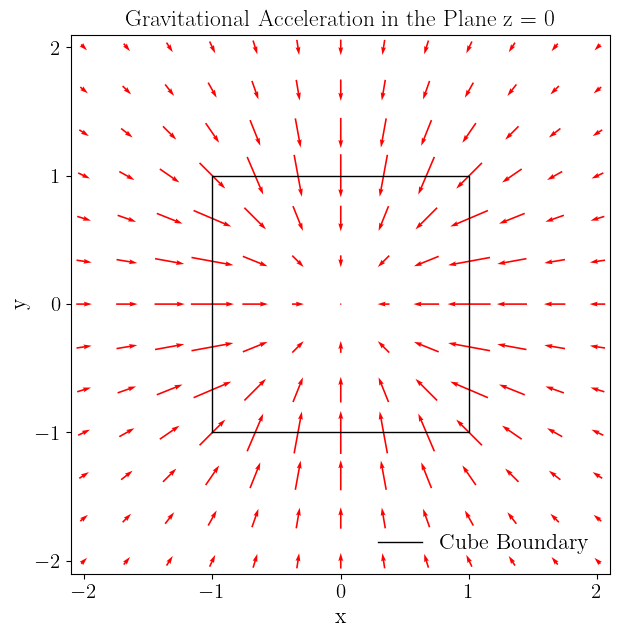

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Import your analytical functions
from utils.potential import Gravitational_potential_cuboid
from utils.acceleration import (
    gravitational_gx_cuboid,
    gravitational_gy_cuboid,
    gravitational_gz_cuboid
)

# ---------------------------------------------------------
# CUBE PARAMETERS
# ---------------------------------------------------------
G = 1
roh = 1
X_0, Y_0, Z_0 = 0, 0, 0
L, B, D = 2.0, 2.0, 2.0   # Full dimensions → semi-dimensions = 1

# Semi-lengths expected by your analytical functions
a = L / 2
b = B / 2
c = D / 2

# ---------------------------------------------------------
# GRID (z = 0 PLANE)
# ---------------------------------------------------------
x_vals = np.linspace(-2, 2, 13)
y_vals = np.linspace(-2, 2, 13)
X, Y = np.meshgrid(x_vals, y_vals)
U = np.zeros_like(X)
V = np.zeros_like(Y)

# ---------------------------------------------------------
# ANALYTICAL ACCELERATION FIELD
# ---------------------------------------------------------
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        xq, yq, zq = X[i, j], Y[i, j], 0.0

        # Use analytical formulas (no numerical differentiation)
        gx = gravitational_gx_cuboid(xq, yq, zq, a, b, c, roh, G)
        gy = gravitational_gy_cuboid(xq, yq, zq, a, b, c, roh, G)

        U[i, j] = gx
        V[i, j] = gy

# ---------------------------------------------------------
# PLOT (unchanged from your original design)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

q = ax.quiver(X, Y, U, V, color='red', scale=65, pivot='middle', width=0.003)

# Cuboid boundary
x_min, x_max = X_0 - L/2, X_0 + L/2
y_min, y_max = Y_0 - B/2, Y_0 + B/2

ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min],
    color='black', linewidth=1, label='Cube Boundary'
)

legend = ax.legend(loc='lower right', frameon=False)
for text in legend.get_texts():
    text.set_color('black')
    text.set_fontsize(16)

ax.set_title("Gravitational Acceleration in the Plane z = 0", fontsize=17, color='black')
ax.set_xlabel('x', fontsize=16, color='black')
ax.set_ylabel('y', fontsize=16, color='black')
ax.tick_params(axis='both', colors='black')

ax.set_xlim([-2.1, 2.1])
ax.set_ylim([-2.1, 2.1])
ax.set_xticks(np.arange(-2, 3, 1))
ax.set_yticks(np.arange(-2, 3, 1))
ax.set_aspect('equal')
ax.grid(False)

plt.savefig("Gravitational_Acceleration_quiver_z0.png", dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# ---------------------------------------------------------
# EXECUTION SCRIPT
# ---------------------------------------------------------

import numpy as np
import pandas as pd
from utils.tensor import (
    gravitational_Vxx_cuboid,
    gravitational_Vyy_cuboid,
    gravitational_Vzz_cuboid,
)

# Constants
G = 1.0
roh = 1.0
X_0, Y_0, Z_0 = 3.0, 3.0, 3.0
L_dim, B_dim, D_dim = 2.0, 2.0, 2.0
epsilon = 1e-10

# Semi-dimensions
a, b, c = L_dim/2, B_dim/2, D_dim/2

test_points = [
    ((3.5, 3.5, 3.5), "Interior (centered below face ABCD)"),
    ((3.5, 3.5, 4.0), "On face ABCD"),
    ((3.5, 3.5, 4.0 + epsilon), "Exterior (above face)"),
    ((3.5, 3.5, 4.0 - epsilon), "Interior (below face)"),
    ((4.0, 4.0, 4.0), "On vertex B"),
    ((4.0, 4.0 + epsilon, 4.0), "On extended edge AB"),
    ((4.0 + epsilon, 4.0, 4.0), "On extended edge CB"),
    ((3.0, 5.0, 4.0), "On extended face ABCD"),
    ((7.0, 7.0, 7.0), "Far exterior point"),
    ((7.0 + epsilon, 7.0 + epsilon, 7.0 + epsilon), "Far exterior + eps")
]

results = []

for (xa, ya, za), desc in test_points:
    xr = xa - X_0
    yr = ya - Y_0
    zr = za - Z_0

    Vxx = gravitational_Vxx_cuboid(xr, yr, zr, a, b, c, roh, G)
    Vyy = gravitational_Vyy_cuboid(xr, yr, zr, a, b, c, roh, G)
    Vzz = gravitational_Vzz_cuboid(xr, yr, zr, a, b, c, roh, G)

    Lap = Vxx + Vyy + Vzz

    results.append({
        "Test Point (Abs)": f"({xa:.10f}, {ya:.10f}, {za:.10f})",
        "Description": desc,
        "Vxx": Vxx,
        "Vyy": Vyy,
        "Vzz": Vzz,
        "Laplacian": Lap
    })

df = pd.DataFrame(results)

print("Gravitational Tensor Laplacian Test Results:")
print(f"Cube Center = ({X_0}, {Y_0}, {Z_0}), Semi-dims = ({a}, {b}, {c})")
print(f"Interior Laplacian = -4πGρ = {-4*np.pi*G*roh:.6f}")
print("--------------------------------------------------------------------------")
print(df.to_string(index=False, float_format="{:.8f}".format))



Gravitational Tensor Laplacian Test Results:
Cube Center = (3.0, 3.0, 3.0), Semi-dims = (1.0, 1.0, 1.0)
Interior Laplacian = -4πGρ = -12.566371
--------------------------------------------------------------------------
                          Test Point (Abs)                         Description         Vxx         Vyy         Vzz    Laplacian
(3.5000000000, 3.5000000000, 3.5000000000) Interior (centered below face ABCD) -4.18879020 -4.18879020 -4.18879020 -12.56637061
(3.5000000000, 3.5000000000, 4.0000000000)                        On face ABCD -2.78199002 -2.78199002 -0.71920527  -6.28318531
(3.5000000000, 3.5000000000, 4.0000000001)               Exterior (above face) -2.78199002 -2.78199002  5.56398003   0.00000000
(3.5000000000, 3.5000000000, 3.9999999999)               Interior (below face) -2.78199002 -2.78199002 -7.00239058 -12.56637061
(4.0000000000, 4.0000000000, 4.0000000000)                         On vertex B -0.52359878 -0.52359878 -0.52359878  -1.57079633
(4.0000000000

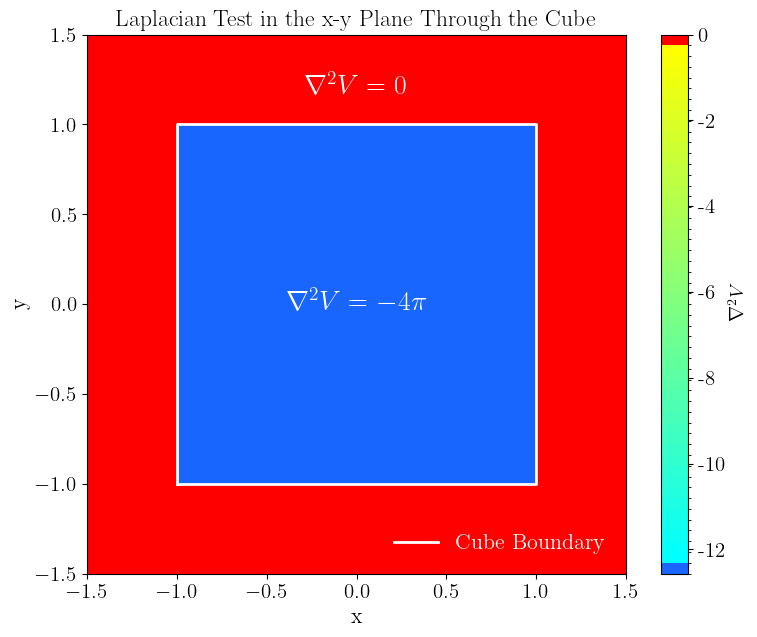

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# -------------------------------------------------------------
# IMPORT ANALYTICAL TENSOR COMPONENTS
# -------------------------------------------------------------
from utils.tensor import (
    gravitational_Vxx_cuboid,
    gravitational_Vyy_cuboid,
    gravitational_Vzz_cuboid
)

# Constants and setup
G = 1
roh = 1
L, B, D = 2.0, 2.0, 2.0
X_0, Y_0, Z_0 = 0.0, 0.0, 0.0  # Center at origin
z_plane = Z_0

# Semi-dimensions for cuboid input
a, b, c = L/2, B/2, D/2

# -------------------------------------------------------------
# ANALYTICAL LAPLACIAN = Vxx + Vyy + Vzz
# -------------------------------------------------------------
def laplacian_analytic(x, y, z):
    x_rel = x - X_0
    y_rel = y - Y_0
    z_rel = z - Z_0

    Vxx = gravitational_Vxx_cuboid(x_rel, y_rel, z_rel, a, b, c, roh, G)
    Vyy = gravitational_Vyy_cuboid(x_rel, y_rel, z_rel, a, b, c, roh, G)
    Vzz = gravitational_Vzz_cuboid(x_rel, y_rel, z_rel, a, b, c, roh, G)

    return Vxx + Vyy + Vzz

# -------------------------------------------------------------
# GRID FOR x-y PLANE
# -------------------------------------------------------------
x_vals = np.linspace(X_0 - L * 0.75, X_0 + L * 0.75, 300)
y_vals = np.linspace(Y_0 - B * 0.75, Y_0 + B * 0.75, 300)
X, Y = np.meshgrid(x_vals, y_vals)

laplace_vals = np.zeros_like(X)

# -------------------------------------------------------------
# COMPUTE ANALYTICAL LAPLACIAN AT EACH GRID POINT
# -------------------------------------------------------------
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        laplace_vals[i, j] = laplacian_analytic(float(X[i, j]), float(Y[i, j]), z_plane)

# -------------------------------------------------------------
# CREATE DISCRETE COLORMAP (UNCHANGED)
# -------------------------------------------------------------
N = 50

colors = [(0.1, 0.4, 1)]  # First color blue
for i in range(1, N-1):
    ratio = (i-1) / (N-3)
    r = ratio
    g = 1.0
    b = 1.0 - ratio
    colors.append((r, g, b))
colors.append((1, 0, 0))  # Last color red

cmap_discrete = ListedColormap(colors)

vmin = -4 * np.pi
vmax = 0
bounds = np.linspace(vmin, vmax, N+1)
norm = BoundaryNorm(bounds, cmap_discrete.N)

# -------------------------------------------------------------
# PLOTTING (NO DESIGN CHANGES)
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    laplace_vals,
    extent=(x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]),
    origin='lower',
    cmap=cmap_discrete,
    norm=norm,
    interpolation='nearest'
)

# Colorbar
cbar = plt.colorbar(im, ax=ax, boundaries=bounds)
tick_positions = [-12, -10, -8, -6, -4, -2, 0]
cbar.set_ticks(tick_positions)
cbar.set_ticklabels([str(t) for t in tick_positions])
cbar.set_label(r'$\nabla^2 V$', fontsize=14)

# Cube boundary (white)
x_min, x_max = X_0 - L/2, X_0 + L/2
y_min, y_max = Y_0 - B/2, Y_0 + B/2
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min],
    color='white',
    linewidth=2,
    label='Cube Boundary'
)

legend = ax.legend(loc='lower right', frameon=False)
for text in legend.get_texts():
    text.set_color('white')
    text.set_fontsize(16)

# Text labels
ax.text(0, 0, r'$\nabla^2 V = -4\pi$', color='white', fontsize=20,
        ha='center', va='center', fontweight='bold')

outside_x = X_0 + L * 0.6
outside_y = Y_0 + B * 0.6
ax.text(0, outside_y, r'$\nabla^2 V = 0$', color='white', fontsize=20,
        ha='center', va='center', fontweight='bold')

# Titles and labels
ax.set_title("Laplacian Test in the x-y Plane Through the Cube", fontsize=17)
ax.set_xlabel('x', fontsize=16)
ax.set_ylabel('y', fontsize=16)
ax.grid(False)

plt.savefig("laplacian_plot.png", dpi=300, bbox_inches='tight')
plt.show()
